# Assignment 1   ChenYuanLong 112021466



Throughout the notebook:

- $\mathbb{E}[X \,\|\, Z]$ denotes the **best affine (least-squares) projection** of $X$ onto $Z$,
- $\operatorname{Cov}(\cdot)$ denotes covariance,
- $\perp_{mc}$ denotes **mean-covariance independence**, i.e. zero cross-covariance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t, chi2, gaussian_kde, probplot, spearmanr, kendalltau, skew, kurtosis, rankdata
from scipy.special import erf
from numpy.linalg import eigh, inv
import math
from pathlib import Path

np.set_printoptions(precision=6, suppress=True)
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path(".")

def _extract_stat(x):
    
    if hasattr(x, "statistic"):
        return float(x.statistic)
    if hasattr(x, "correlation"):
        return float(x.correlation)
    try:
        return float(x[0])
    except Exception:
        return float(x)


## 1. The Lognormal Distribution

### 1(a) Derivation of the mode

Let

$$
X \sim \operatorname{LogN}(\mu,\sigma^2),
$$

so that $Y=\ln X \sim N(\mu,\sigma^2)$. Its density is

$$
f_X(x)=\frac{1}{x\sigma\sqrt{2\pi}}
\exp\!\left(-\frac{(\ln x-\mu)^2}{2\sigma^2}\right),\qquad x>0.
$$


The mode is the maximizer of $f_X(x)$, equivalently of $\log f_X(x)$:

$$
\log f_X(x)
=
-\log x-\log(\sigma\sqrt{2\pi})
-\frac{(\ln x-\mu)^2}{2\sigma^2}.
$$


Ignoring the constant term and differentiating with respect to $x$,

$$
\frac{d}{dx}\log f_X(x)
=
-\frac1x-\frac{\ln x-\mu}{\sigma^2 x}
=
-\frac{1}{x}\left(1+\frac{\ln x-\mu}{\sigma^2}\right).
$$


Setting this equal to zero gives

$$
1+\frac{\ln x-\mu}{\sigma^2}=0
\quad\Longrightarrow\quad
\ln x=\mu-\sigma^2.
$$


Hence the mode is

$$
\boxed{\operatorname{Mode}(X)=e^{\mu-\sigma^2}}.
$$


Because the derivative changes sign from positive to negative at $x=e^{\mu-\sigma^2}$, this critical point is indeed a maximum.

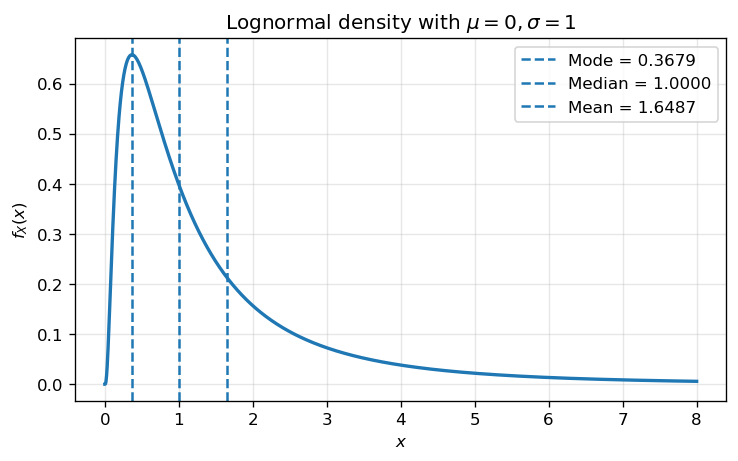

Mode   = 0.36787944117144233
Median = 1.0
Mean   = 1.6487212707001282


In [2]:
# Q1(b): visualization for mu=0, sigma=1
mu_ln = 0.0
sigma_ln = 1.0

x = np.linspace(1e-3, 8, 2000)
pdf = (1 / (x * sigma_ln * np.sqrt(2*np.pi))) * np.exp(-(np.log(x)-mu_ln)**2 / (2*sigma_ln**2))

mode_ln = np.exp(mu_ln - sigma_ln**2)
median_ln = np.exp(mu_ln)
mean_ln = np.exp(mu_ln + sigma_ln**2/2)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(x, pdf, lw=2)
ax.axvline(mode_ln, ls='--', lw=1.5, label=f"Mode = {mode_ln:.4f}")
ax.axvline(median_ln, ls='--', lw=1.5, label=f"Median = {median_ln:.4f}")
ax.axvline(mean_ln, ls='--', lw=1.5, label=f"Mean = {mean_ln:.4f}")
ax.set_title(r"Lognormal density with $\mu=0, \sigma=1$")
ax.set_xlabel("$x$")
ax.set_ylabel("$f_X(x)$")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print("Mode   =", mode_ln)
print("Median =", median_ln)
print("Mean   =", mean_ln)

For $X\sim \operatorname{LogN}(0,1)$,

$$
\operatorname{Mode}(X)=e^{-1}\approx 0.3679,\qquad
\operatorname{Median}(X)=1,\qquad
\mathbb{E}[X]=e^{1/2}\approx 1.6487.
$$


Thus

$$
\boxed{\operatorname{Mode}<\operatorname{Median}<\operatorname{Mean}},
$$

which is the usual right-skewed ordering for the lognormal distribution.

## 2. Elicitability of the Quantile

Let $0<\tau<1$. The $\tau$-quantile set of a distribution $F$ is

$$
Q_\tau(F)=\{a\in\mathbb{R}:F(a^-)\le \tau \le F(a)\}.
$$

If $F$ is continuous and strictly increasing at the quantile, this set reduces to the singleton $ \{q_\tau(F)\} $, where

$$
q_\tau(F)=\inf\{a\in\mathbb{R}:F(a)\ge \tau\}.
$$

Consider the **check loss**

$$
\rho_\tau(u)=
\begin{cases}
\tau u, & u\ge 0,\\
(\tau-1)u, & u<0.
\end{cases}
$$

Equivalently, for an action $a$,

$$
\ell_\tau(x,a)=\rho_\tau(x-a)=
\begin{cases}
\tau(x-a), & x\ge a,\\
(1-\tau)(a-x), & x<a.
\end{cases}
$$

Define

$$
L(a)=\mathbb{E}[\ell_\tau(X,a)].
$$

In the continuous case,

$$
L(a)
=
\int_{-\infty}^a (1-\tau)(a-x)\,dF(x)
+
\int_a^\infty \tau(x-a)\,dF(x).
$$

Differentiating with respect to $a$ gives

$$
L'(a)=F(a)-\tau.
$$

Hence any stationary point satisfies $F(a)=\tau$, and since $L$ is convex, this stationary point is a global minimizer.

In the general (possibly discontinuous) case, convexity still holds, and the one-sided derivatives are

$$
L'_-(a)=F(a^-)-\tau,
\qquad
L'_+(a)=F(a)-\tau.
$$

Therefore $a$ minimizes $L$ if and only if

$$
L'_-(a)\le 0 \le L'_+(a),
$$

that is,

$$
F(a^-)\le \tau \le F(a).
$$

So the full minimizer set is exactly the $\tau$-quantile set:

$$
\boxed{
\arg\min_{a\in\mathbb{R}} \mathbb{E}[\ell_\tau(X,a)]
=
Q_\tau(F).
}
$$

Thus the quantile is an **elicitable functional**. In particular, when the quantile is unique (for example, under continuity and strict monotonicity at the quantile), the unique minimizer is $q_\tau(F)$.

## 3. Conditional Independence / Markov Property

Assume the relevant conditional densities exist and that $f(y\mid z)>0$. If

$$
X \perp\!\!\!\perp Y \mid Z,
$$

then by conditional independence,

$$
f(x,y\mid z)=f(x\mid z)f(y\mid z).
$$

Therefore,

$$
f(x\mid z,y)=\frac{f(x,y\mid z)}{f(y\mid z)}
=\frac{f(x\mid z)f(y\mid z)}{f(y\mid z)}
=f(x\mid z).
$$

Hence

$$
\boxed{
X \perp\!\!\!\perp Y \mid Z
\;\Longrightarrow\;
f(x\mid z,y)=f(x\mid z)
\quad \text{(whenever the conditional densities exist and }f(y\mid z)>0\text{).}
}
$$

Equivalently, in the more general measure-theoretic form, for every measurable set $A$,

$$
\mathbb{P}(X\in A\mid Y,Z)=\mathbb{P}(X\in A\mid Z)\qquad \text{a.s.}
$$

So once $Z$ is given, knowing $Y$ provides no additional information about $X$.

## 4. Copula Properties

### 4(a) Probability integral transform

Assume $F_X$ is continuous and define

$$
U=F_X(X).
$$

Then for any $u\in[0,1]$,

$$
\mathbb{P}(U\le u)
=
\mathbb{P}(F_X(X)\le u)
=
\mathbb{P}(X\le F_X^{-1}(u))
=
F_X(F_X^{-1}(u))
=
u.
$$

Hence

$$
\boxed{U\sim \operatorname{Unif}(0,1)}.
$$


### 4(b) Copula density formula

By Sklar's theorem,

$$
F_X(x_1,\dots,x_n)
=
C(F_{X_1}(x_1),\dots,F_{X_n}(x_n)).
$$

Let $u_i=F_{X_i}(x_i)$. Differentiating both sides with respect to all coordinates,

$$
f_X(x_1,\dots,x_n)
=
c_X(u_1,\dots,u_n)\prod_{i=1}^n f_{X_i}(x_i),
$$

where

$$
c_X(u_1,\dots,u_n)=
\frac{\partial^n C(u_1,\dots,u_n)}{\partial u_1\cdots\partial u_n}.
$$


Now substitute $x_i=q_{X_i}(u_i)=F_{X_i}^{-1}(u_i)$:

$$
f_X(q_{X_1}(u_1),\dots,q_{X_n}(u_n))
=
c_X(u_1,\dots,u_n)\prod_{i=1}^n f_{X_i}(q_{X_i}(u_i)).
$$

Therefore

$$
\boxed{
c_X(u_1,\dots,u_n)=
\frac{
f_X(q_{X_1}(u_1),\dots,q_{X_n}(u_n))
}{
\prod_{i=1}^n f_{X_i}(q_{X_i}(u_i))
}.
}
$$


## 5. Copula Simulations

In [3]:
def sample_gaussian_copula(n, rho, seed=None):
    rng = np.random.default_rng(seed)
    Sigma = np.array([[1, rho], [rho, 1]])
    z = rng.multivariate_normal([0, 0], Sigma, size=n)
    u = norm.cdf(z)
    return u

def sample_t_copula(n, rho, nu, seed=None):
    rng = np.random.default_rng(seed)
    Sigma = np.array([[1, rho], [rho, 1]])
    z = rng.multivariate_normal([0, 0], Sigma, size=n)
    s = rng.chisquare(df=nu, size=n)
    y = z / np.sqrt(s[:, None] / nu)
    u = t.cdf(y, df=nu)
    return u

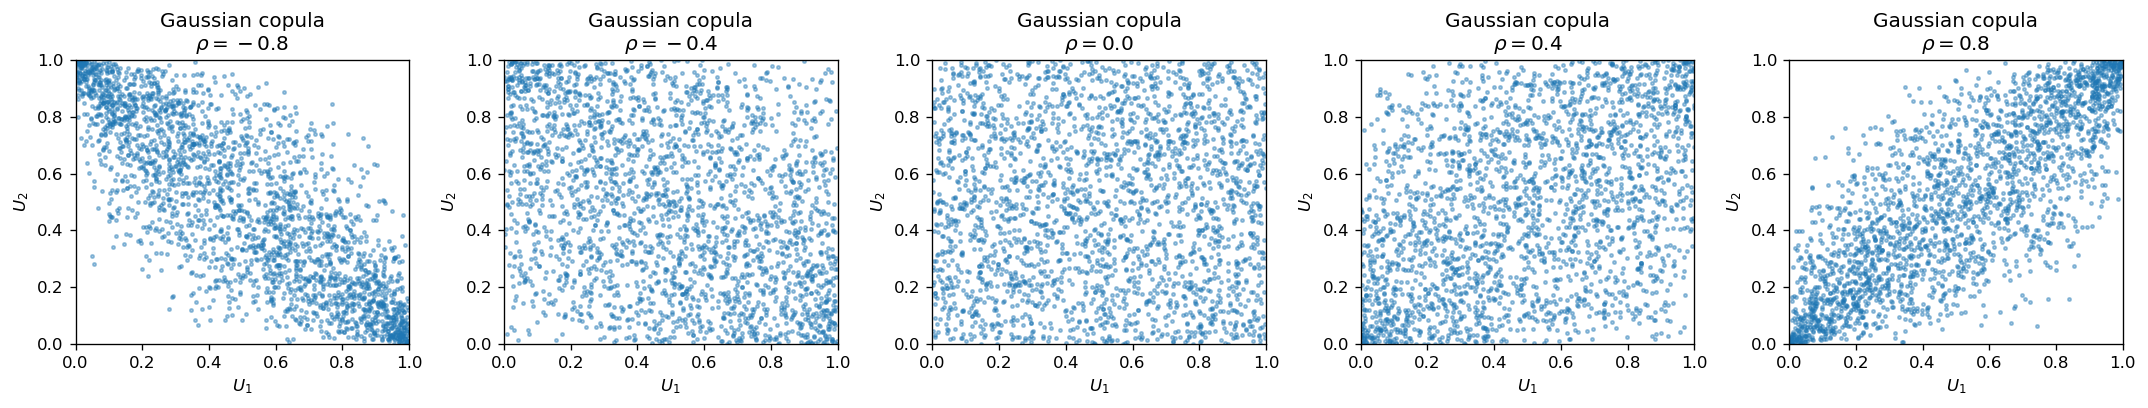

In [4]:
# Gaussian copula across different correlations
rhos = [-0.8, -0.4, 0.0, 0.4, 0.8]
fig, axes = plt.subplots(1, len(rhos), figsize=(18, 3.5))
for ax, rho in zip(axes, rhos):
    U = sample_gaussian_copula(2500, rho, seed=42 + int((rho+1)*10))
    ax.scatter(U[:,0], U[:,1], s=4, alpha=0.4)
    ax.set_title(f"Gaussian copula\n$\\rho={rho}$")
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("$U_1$"); ax.set_ylabel("$U_2$")
plt.tight_layout()
plt.show()

As $\rho$ increases, the points concentrate more strongly along the diagonal $u_1=u_2$.  
For negative $\rho$, the cloud tilts in the opposite direction.  
At $\rho=0$, the cloud is approximately uniform in the unit square, indicating near independence.

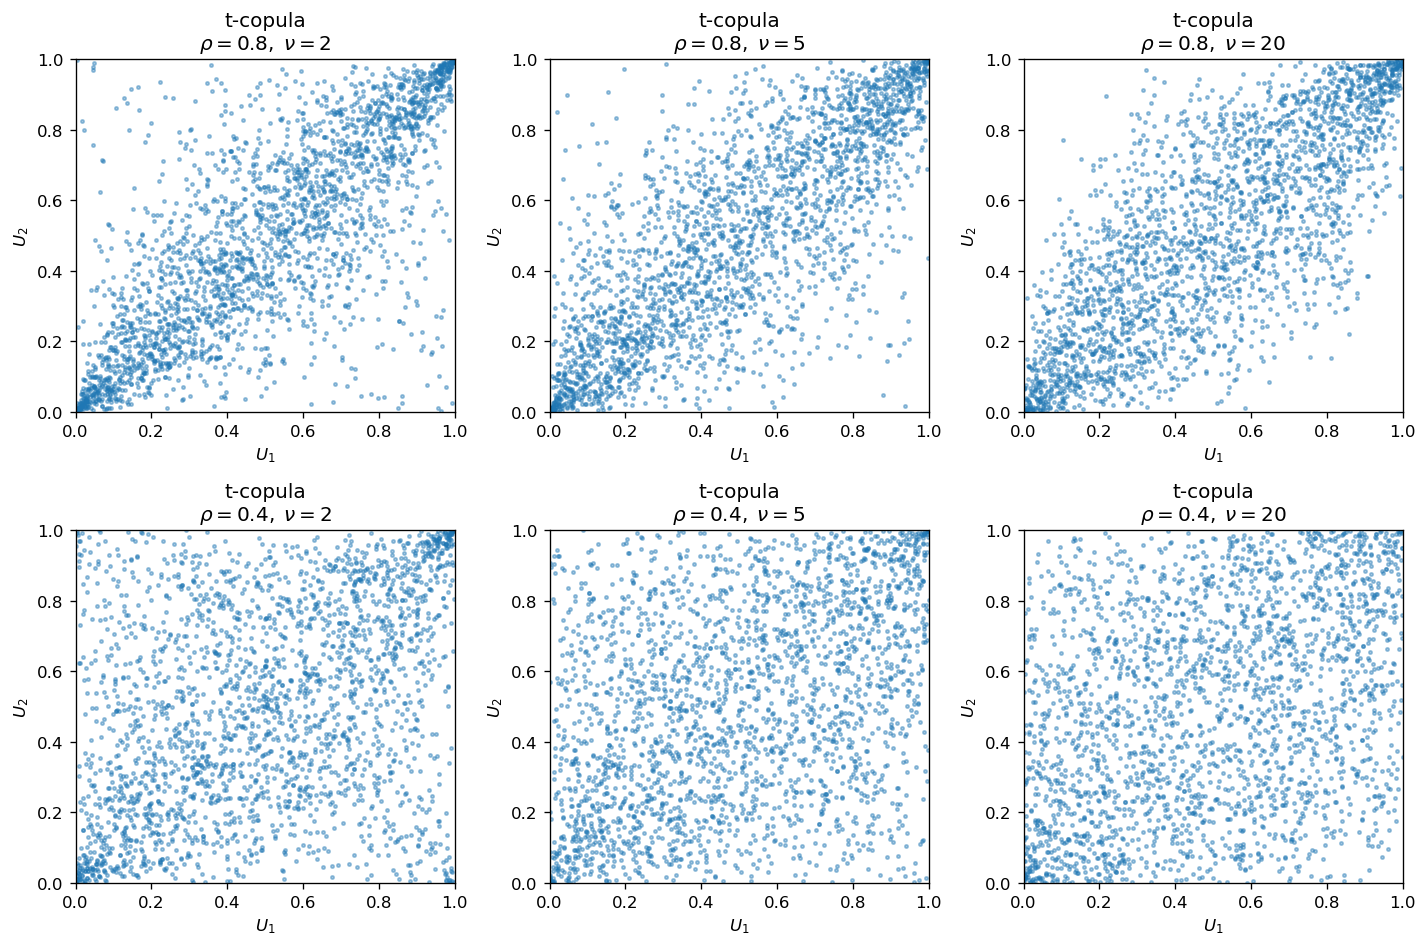

In [5]:
# Student t copula: varying rho and nu
settings = [(0.8, 2), (0.8, 5), (0.8, 20), (0.4, 2), (0.4, 5), (0.4, 20)]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (rho, nu) in zip(axes.ravel(), settings):
    U = sample_t_copula(2500, rho, nu, seed=100 + int(10*rho) + nu)
    ax.scatter(U[:,0], U[:,1], s=4, alpha=0.4)
    ax.set_title(f"t-copula\n$\\rho={rho},\\;\\nu={nu}$")
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel("$U_1$"); ax.set_ylabel("$U_2$")
plt.tight_layout()
plt.show()

For the t-copula, smaller $\nu$ produces stronger clustering near the corners of the unit square, reflecting **tail dependence**.  
As $\nu\to\infty$, the t-copula approaches the Gaussian copula.

## 6. Mean-Covariance Analysis (Section 4.1)

The assignment specifies a shifted bivariate lognormal model for annual linear returns:

$$
\begin{bmatrix}1+X_1\\1+X_2\end{bmatrix}
\sim \operatorname{LogN}(\mu,\Sigma),
$$

with

$$
\mu=
\begin{bmatrix}0.10\\0.08\end{bmatrix},
\qquad
\Sigma=
\begin{bmatrix}
0.35^2 & -0.60(0.35)(0.30)\\
-0.60(0.35)(0.30) & 0.30^2
\end{bmatrix}
=
\begin{bmatrix}
0.1225 & -0.063\\
-0.063 & 0.09
\end{bmatrix}.
$$


For a lognormal random variable $Y_i=e^{Z_i}$, we have

$$
\mathbb{E}[Y_i]=\exp\!\left(\mu_i+\frac12\sigma_{ii}\right),
$$

so here

$$
\mathbb{E}[X_i]=\exp\!\left(\mu_i+\frac12\sigma_{ii}\right)-1.
$$


The covariance formula is

$$
\operatorname{Cov}(X_i,X_j)=\operatorname{Cov}(Y_i,Y_j)
=
\exp\!\left(\mu_i+\frac12\sigma_{ii}\right)
\exp\!\left(\mu_j+\frac12\sigma_{jj}\right)
\bigl(e^{\sigma_{ij}}-1\bigr).
$$


In [6]:
# Section 4.1 parameters
mu_q6 = np.array([0.10, 0.08])
Sigma_q6 = np.array([
    [0.35**2, -0.60*0.35*0.30],
    [-0.60*0.35*0.30, 0.30**2]
])

mean_q6 = np.exp(mu_q6 + 0.5*np.diag(Sigma_q6)) - 1

cov_q6 = np.zeros((2,2))
for i in range(2):
    for j in range(2):
        cov_q6[i,j] = (
            np.exp(mu_q6[i] + 0.5*Sigma_q6[i,i])
            * np.exp(mu_q6[j] + 0.5*Sigma_q6[j,j])
            * (np.exp(Sigma_q6[i,j]) - 1)
        )

std_q6 = np.sqrt(np.diag(cov_q6))
corr_q6 = cov_q6[0,1] / (std_q6[0]*std_q6[1])

eigvals_q6, eigvecs_q6 = eigh(cov_q6)
idx = np.argsort(eigvals_q6)[::-1]
eigvals_q6 = eigvals_q6[idx]
eigvecs_q6 = eigvecs_q6[:, idx]
explained_q6 = eigvals_q6 / eigvals_q6.sum()

w = np.array([0.2, 0.8])
port_mean_q6 = w @ mean_q6
port_var_q6 = w @ cov_q6 @ w
port_sd_q6 = np.sqrt(port_var_q6)

summary_q6 = pd.DataFrame({
    "Quantity": [
        "E[X1]", "E[X2]",
        "Var(X1)", "Var(X2)", "Cov(X1,X2)", "Corr(X1,X2)",
        "sd(X1)", "sd(X2)",
        "lambda1", "lambda2",
        "Explained variance PC1", "Explained variance PC2",
        "Portfolio mean", "Portfolio variance", "Portfolio volatility"
    ],
    "Value": [
        mean_q6[0], mean_q6[1],
        cov_q6[0,0], cov_q6[1,1], cov_q6[0,1], corr_q6,
        std_q6[0], std_q6[1],
        eigvals_q6[0], eigvals_q6[1],
        explained_q6[0], explained_q6[1],
        port_mean_q6, port_var_q6, port_sd_q6
    ]
})
summary_q6

,Quantity,Value
0,E[X1],0.174979
1,E[X2],0.133148
2,Var(X1),0.179915
3,Var(X2),0.120922
4,"Cov(X1,X2)",-0.081292
5,"Corr(X1,X2)",-0.551140
6,sd(X1),0.424164
7,sd(X2),0.347739
8,lambda1,0.236897
9,lambda2,0.063941


The theoretical mean vector is approximately

$$
\boxed{
\mathbb{E}[X]\approx
\begin{bmatrix}
0.17498\\
0.13315
\end{bmatrix}
=
\begin{bmatrix}
17.5\%\\
13.3\%
\end{bmatrix}.
}
$$


The covariance matrix is

$$
\boxed{
\operatorname{Cov}(X)\approx
\begin{bmatrix}
0.179915 & -0.081292\\
-0.081292 & 0.120922
\end{bmatrix}.
}
$$


Hence the standardized variables (z-scores) are

$$
Z_1=\frac{X_1-0.17498}{0.42416},
\qquad
Z_2=\frac{X_2-0.13315}{0.34774}.
$$


The portfolio with weights $w=(0.2,0.8)^\top$ has

$$
\mu_p=w^\top \mathbb{E}[X]\approx 0.14151,
\qquad
\sigma_p^2=w^\top \operatorname{Cov}(X)w\approx 0.05857.
$$


For any observed return vector $x=(x_1,x_2)$, the corresponding z-score vector is computed componentwise as

$$
z(x)=\left(\frac{x_1-\mathbb{E}[X_1]}{\sqrt{\operatorname{Var}(X_1)}},\;
\frac{x_2-\mathbb{E}[X_2]}{\sqrt{\operatorname{Var}(X_2)}}\right),
$$

and in code this is implemented rowwise as `z = (x - mean_q6) / std_q6`.


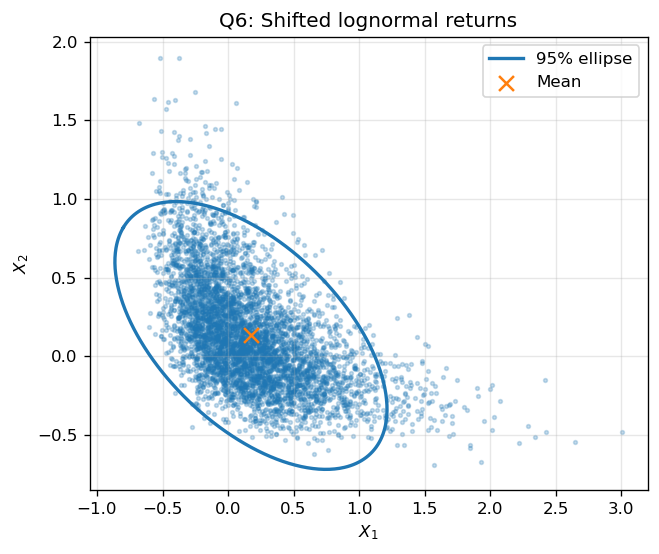

In [7]:
# Simulated cloud and 95% mean-covariance ellipse for Q6
rng = np.random.default_rng(123)
Z = rng.multivariate_normal(mu_q6, Sigma_q6, size=5000)
Y = np.exp(Z)
X = Y - 1

alpha = 0.95
c = chi2.ppf(alpha, df=2)
theta = np.linspace(0, 2*np.pi, 400)
circle = np.vstack((np.cos(theta), np.sin(theta)))
ellipse = mean_q6.reshape(2,1) + eigvecs_q6 @ np.diag(np.sqrt(c * eigvals_q6)) @ circle

fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(X[:,0], X[:,1], s=5, alpha=0.25)
ax.plot(ellipse[0,:], ellipse[1,:], lw=2, label="95% ellipse")
ax.scatter(mean_q6[0], mean_q6[1], marker='x', s=80, label="Mean")
ax.set_title("Q6: Shifted lognormal returns")
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

The first principal component explains most of the total variance, and the ellipse is tilted downward because the two returns are negatively correlated.

## 7. Linear Independence and Normal Coincidence

### 7(a) Affine invariance of mean-covariance independence

Using the equivalent characterization of mean-covariance independence by vanishing cross-covariance, write

$$
X \perp_{mc} Z
\quad\Longleftrightarrow\quad
\mathrm{Cv}\{X,Z\}=0.
$$

Let

$$
X^\star=a_X+b_X X,
\qquad
Z^\star=a_Z+b_Z Z,
$$

where $a_X,a_Z$ are constants and $b_X,b_Z$ are conformable matrices (or scalars in the one-dimensional case). Then

$$
\mathrm{Cv}\{X^\star,Z^\star\}
=
\mathrm{Cv}\{a_X+b_X X,\;a_Z+b_Z Z\}
=
b_X\,\mathrm{Cv}\{X,Z\}\,b_Z^\top.
$$

Therefore

$$
\mathrm{Cv}\{X,Z\}=0
\quad\Longleftrightarrow\quad
\mathrm{Cv}\{X^\star,Z^\star\}=0,
$$

so

$$
\boxed{
X \perp_{mc} Z
\;\Longleftrightarrow\;
a_X+b_X X \perp_{mc} a_Z+b_Z Z.
}
$$


### 7(b) Residual properties

Let

$$
m(Z)=\mathbb{E}[X\|Z],
\qquad
\tilde\varepsilon=X-m(Z),
$$

where $\mathbb{E}[X\|Z]$ denotes the best affine least-squares predictor of $X$ from $Z$.

By the orthogonality principle of linear projection, the residual is orthogonal to the affine span of $Z$. Since affine functions include constants and all expressions of the form $a+bZ$, we get:

1. Orthogonality to constants gives
$$
\mathbb{E}[\tilde\varepsilon]=0.
$$

2. Orthogonality to any affine transform $a+bZ$ gives
$$
\mathrm{Cv}\{\tilde\varepsilon,\;a+bZ\}=0.
$$

Hence

$$
\boxed{
\mathbb{E}[\tilde\varepsilon]=0,
\qquad
\mathrm{Cv}\{\tilde\varepsilon,\;a+bZ\}=0
\text{ for every affine transform }a+bZ.
}
$$


### 7(c) Total covariance decomposition

From the projection decomposition,

$$
X = m(Z)+\tilde\varepsilon.
$$

Therefore

$$
\mathrm{Cv}\{X\}
=
\mathrm{Cv}\{m(Z)+\tilde\varepsilon\}
=
\mathrm{Cv}\{m(Z)\}+\mathrm{Cv}\{\tilde\varepsilon\},
$$

because the cross terms vanish by part (b):

$$
\mathrm{Cv}\{m(Z),\tilde\varepsilon\}=0.
$$

Now define the linear conditional covariance by

$$
\mathrm{Cv}\{X\|Z\}
=
\mathbb{E}\!\left[\tilde\varepsilon\tilde\varepsilon^\top\mid Z\right].
$$

Taking expectations and using $\mathbb{E}[\tilde\varepsilon]=0$, we obtain

$$
\mathbb{E}[\mathrm{Cv}\{X\|Z\}]
=
\mathbb{E}\!\left[\tilde\varepsilon\tilde\varepsilon^\top\right]
=
\mathrm{Cv}\{\tilde\varepsilon\}.
$$

Since $m(Z)=\mathbb{E}[X\|Z]$, it follows that

$$
\boxed{
\mathrm{Cv}\{X\}
=
\mathbb{E}[\mathrm{Cv}\{X\|Z\}]
+
\mathrm{Cv}\{\mathbb{E}[X\|Z]\}.
}
$$


### 7(d) Normal coincidence

Suppose $(X,Y,Z)$ is jointly multivariate normal. For $(X,Z)$ we may write

$$
\begin{bmatrix}X\\ Z\end{bmatrix}
\sim
N\!\left(
\begin{bmatrix}\mu_X\\ \mu_Z\end{bmatrix},
\begin{bmatrix}
\Sigma_{XX} & \Sigma_{XZ}\\
\Sigma_{ZX} & \Sigma_{ZZ}
\end{bmatrix}
\right).
$$

Then the usual Gaussian conditioning formula gives

$$
\mathbb{E}[X\mid Z]
=
\mu_X+\Sigma_{XZ}\Sigma_{ZZ}^{-1}(Z-\mu_Z),
$$

which is an affine function of $Z$. Hence the linear projection and the conditional expectation coincide:

$$
\boxed{
\mathbb{E}^N[X\|Z]=\mathbb{E}^N[X\mid Z].
}
$$

The Gaussian conditional covariance is

$$
\mathrm{Cv}^N\{X\mid Z\}
=
\Sigma_{XX}-\Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZX},
$$

which is constant in $Z$. This is exactly the covariance of the projection residual, so

$$
\boxed{
\mathrm{Cv}^N\{X\|Z\}=\mathrm{Cv}^N\{X\mid Z\}.
}
$$

For jointly Gaussian vectors, zero conditional cross-covariance is equivalent to conditional independence. Writing

$$
\Sigma_{XY\cdot Z}
=
\Sigma_{XY}-\Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZY},
$$

we therefore have

$$
X \perp_{mc} Y \mid Z
\quad\Longleftrightarrow\quad
\Sigma_{XY\cdot Z}=0
\quad\Longleftrightarrow\quad
X \perp\!\!\!\perp Y \mid Z.
$$

Hence under joint normality,

$$
\boxed{
X \perp_{mc} Y \mid Z
\;\Longleftrightarrow\;
X \perp\!\!\!\perp Y \mid Z.
}
$$


## 8. Projection and Residuals (Section 6.3 Example)

Using the formulas displayed in the provided Section 6.3, let

$$
\varepsilon_1,\varepsilon_2,\varepsilon_3 \stackrel{iid}{\sim} N(0,1),
$$

and define

$$
X_1=\varepsilon_1+\frac15\varepsilon_2+\cos(\varepsilon_2)+\frac15\varepsilon_3^3,
$$


$$
X_2=\frac15\varepsilon_2+\frac{(e-1)^2}{6e^2}\varepsilon_3-\cos(\varepsilon_2)+\frac15\varepsilon_3^3,
$$


$$
Z=1-\frac23(\varepsilon_2+\varepsilon_3^3).
$$


We now compute the best affine projections

$$
\widehat X_i=\alpha_i+\beta_i Z
$$

and the residuals

$$
\eta_i=X_i-\widehat X_i,\qquad i=1,2.
$$


In [8]:
# Section 6.3 simulation and affine projections
rng = np.random.default_rng(2025)
n = 4000
eps1 = rng.normal(size=n)
eps2 = rng.normal(size=n)
eps3 = rng.normal(size=n)

coef = (math.e - 1)**2 / (6 * math.e**2)

X1 = eps1 + 0.2*eps2 + np.cos(eps2) + 0.2*eps3**3
X2 = 0.2*eps2 + coef*eps3 - np.cos(eps2) + 0.2*eps3**3
Z = 1 - (2/3)*(eps2 + eps3**3)

def affine_projection(x, z):
    beta = np.cov(x, z, ddof=1)[0,1] / np.var(z, ddof=1)
    alpha = x.mean() - beta * z.mean()
    fitted = alpha + beta * z
    resid = x - fitted
    return alpha, beta, fitted, resid

a1, b1, X1_hat, eta1 = affine_projection(X1, Z)
a2, b2, X2_hat, eta2 = affine_projection(X2, Z)

proj_summary = pd.DataFrame({
    "variable": ["X1", "X2"],
    "alpha": [a1, a2],
    "beta": [b1, b2],
    "cov(residual, Z)": [np.cov(eta1, Z, ddof=1)[0,1], np.cov(eta2, Z, ddof=1)[0,1]]
})
proj_summary

,variable,alpha,beta,"cov(residual, Z)"
0,X1,0.880147,-0.298408,-2.212117e-16
1,X2,-0.272954,-0.320450,-9.098332e-16


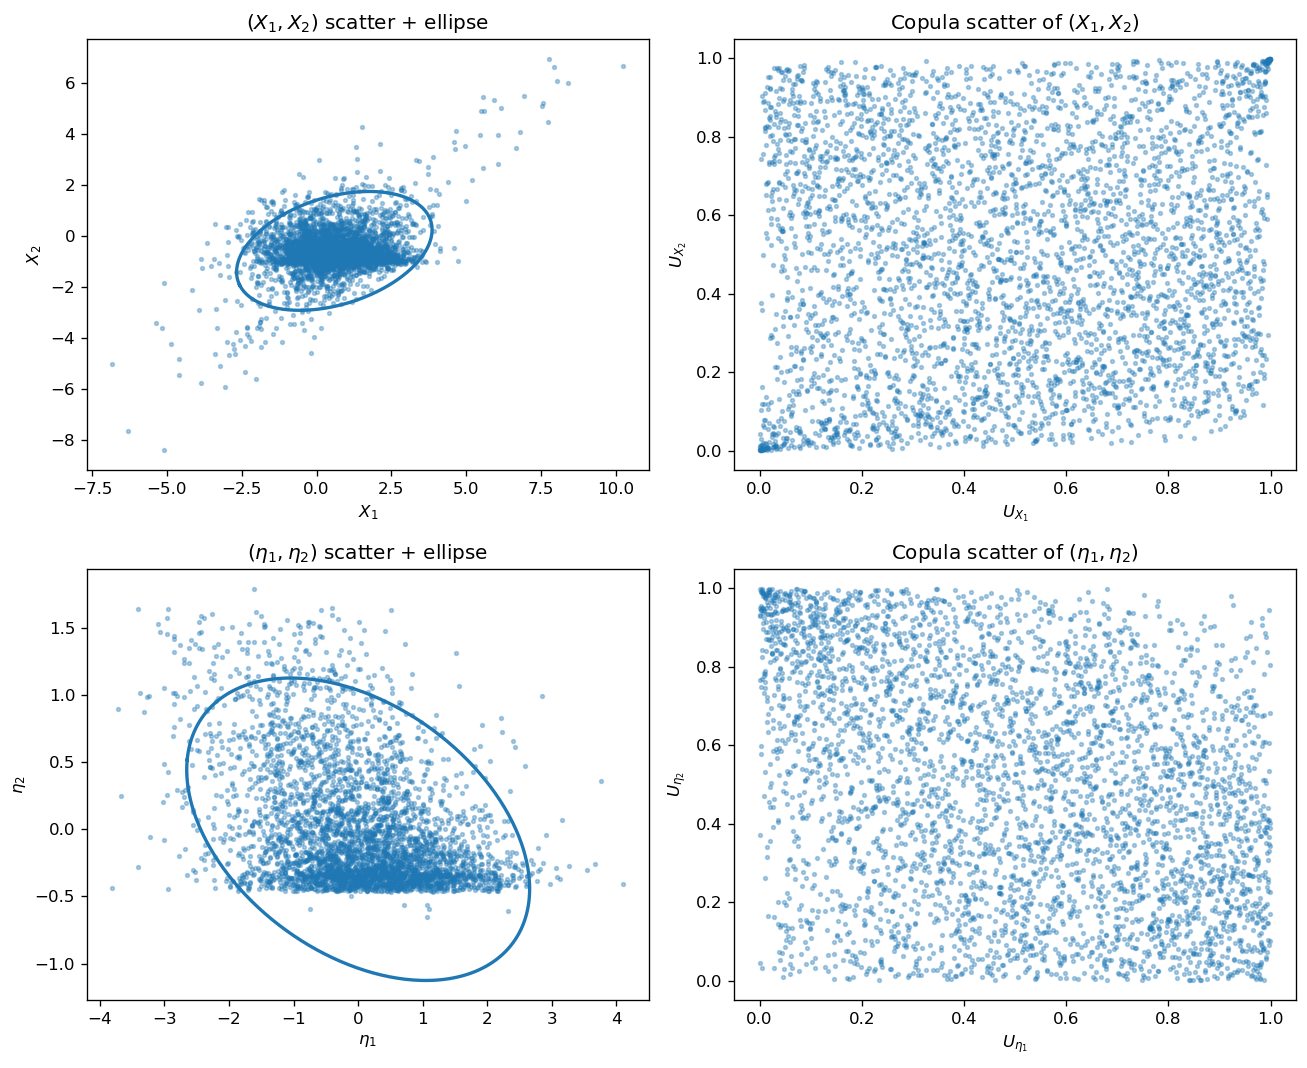

Sample covariance of (X1, X2): 0.4514759459720341
Sample covariance of residuals: -0.1961623000639291


In [9]:
def empirical_copula_uv(x, y):
    u = rankdata(x, method="average") / (len(x) + 1.0)
    v = rankdata(y, method="average") / (len(y) + 1.0)
    return u, v

def ellipse_from_mean_cov(mu, Sigma, level=0.95):
    vals, vecs = eigh(Sigma)
    idx = np.argsort(vals)[::-1]
    vals = vals[idx]
    vecs = vecs[:, idx]
    c = chi2.ppf(level, df=2)
    theta = np.linspace(0, 2*np.pi, 400)
    circle = np.vstack((np.cos(theta), np.sin(theta)))
    ellipse = mu.reshape(2,1) + vecs @ np.diag(np.sqrt(c * vals)) @ circle
    return ellipse

# Original pair
mu_x = np.array([X1.mean(), X2.mean()])
Sigma_x = np.cov(np.vstack([X1, X2]), ddof=1)
ellipse_x = ellipse_from_mean_cov(mu_x, Sigma_x)
u_x1, u_x2 = empirical_copula_uv(X1, X2)

# Residual pair
mu_eta = np.array([eta1.mean(), eta2.mean()])
Sigma_eta = np.cov(np.vstack([eta1, eta2]), ddof=1)
ellipse_eta = ellipse_from_mean_cov(mu_eta, Sigma_eta)
u_eta1, u_eta2 = empirical_copula_uv(eta1, eta2)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

axes[0,0].scatter(X1, X2, s=5, alpha=0.35)
axes[0,0].plot(ellipse_x[0], ellipse_x[1], lw=2)
axes[0,0].set_title(r"$(X_1, X_2)$ scatter + ellipse")
axes[0,0].set_xlabel("$X_1$")
axes[0,0].set_ylabel("$X_2$")

axes[0,1].scatter(u_x1, u_x2, s=5, alpha=0.35)
axes[0,1].set_title(r"Copula scatter of $(X_1, X_2)$")
axes[0,1].set_xlabel("$U_{X_1}$")
axes[0,1].set_ylabel("$U_{X_2}$")

axes[1,0].scatter(eta1, eta2, s=5, alpha=0.35)
axes[1,0].plot(ellipse_eta[0], ellipse_eta[1], lw=2)
axes[1,0].set_title(r"$(\eta_1, \eta_2)$ scatter + ellipse")
axes[1,0].set_xlabel("$\eta_1$")
axes[1,0].set_ylabel("$\eta_2$")

axes[1,1].scatter(u_eta1, u_eta2, s=5, alpha=0.35)
axes[1,1].set_title(r"Copula scatter of $(\eta_1, \eta_2)$")
axes[1,1].set_xlabel("$U_{\eta_1}$")
axes[1,1].set_ylabel("$U_{\eta_2}$")

plt.tight_layout()
plt.show()

print("Sample covariance of (X1, X2):", np.cov(X1, X2, ddof=1)[0,1])
print("Sample covariance of residuals:", np.cov(eta1, eta2, ddof=1)[0,1])

The simulation shows a strong nonlinear dependence in $(X_1,X_2)$.  
After removing the best affine part explained by $Z$, the residual cloud changes shape substantially.  
By construction of least-squares projection, each residual is orthogonal to $Z$, which is visible in the table above through near-zero sample covariances $\operatorname{Cov}(\eta_i,Z)$.

## 9. Dataset Evaluation: BTC and ETH (4-hour data)

We use the uploaded files:

- `BTCUSDT_4h_merged.csv`
- `ETHUSDT_4h_merged.csv`

and analyze the aligned 4-hour returns using the column `return_1`.



In [10]:
# Load and align BTC / ETH returns
required_files = ["BTCUSDT_4h_merged.csv", "ETHUSDT_4h_merged.csv"]
candidate_dirs = [Path("."), Path("/mnt/data")]

for candidate in candidate_dirs:
    if all((candidate / fname).exists() for fname in required_files):
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError(
        
    )

btc = pd.read_csv(DATA_DIR / "BTCUSDT_4h_merged.csv", parse_dates=["open_time"])
eth = pd.read_csv(DATA_DIR / "ETHUSDT_4h_merged.csv", parse_dates=["open_time"])

df = (
    btc[["open_time", "return_1"]].rename(columns={"return_1": "btc"})
    .merge(
        eth[["open_time", "return_1"]].rename(columns={"return_1": "eth"}),
        on="open_time",
        how="inner",
    )
    .dropna()
    .sort_values("open_time")
    .reset_index(drop=True)
)

df.head(), len(df)


(                  open_time       btc       eth
 0 2024-01-01 04:00:00+00:00  0.003819  0.004765
 1 2024-01-01 08:00:00+00:00  0.004643  0.008629
 2 2024-01-01 12:00:00+00:00  0.002173  0.004429
 3 2024-01-01 16:00:00+00:00  0.017032  0.009699
 4 2024-01-01 20:00:00+00:00  0.015088  0.006304,
 4866)

In [11]:
# Summary statistics
summary_q9 = pd.DataFrame({
    "mean": [df["btc"].mean(), df["eth"].mean()],
    "std": [df["btc"].std(ddof=1), df["eth"].std(ddof=1)],
    "skewness": [skew(df["btc"], bias=False), skew(df["eth"], bias=False)],
    "excess_kurtosis": [kurtosis(df["btc"], fisher=True, bias=False), kurtosis(df["eth"], fisher=True, bias=False)],
}, index=["BTC", "ETH"])

summary_q9

,mean,std,skewness,excess_kurtosis
BTC,0.000101,0.010338,-0.169604,6.176280
ETH,-0.000015,0.014580,-0.520019,9.154821


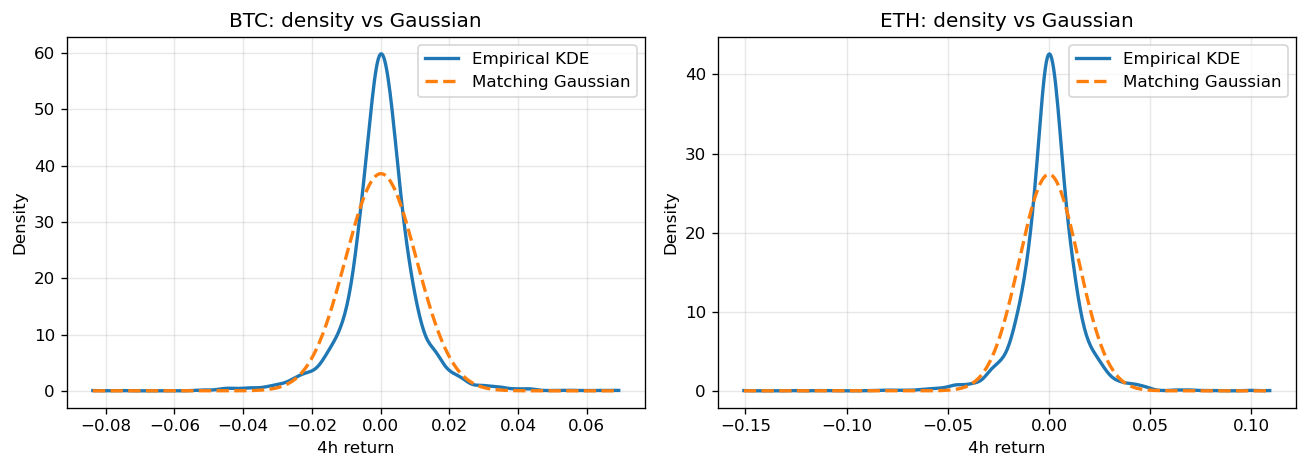

In [12]:
# Density plot with Gaussian overlay
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, name in zip(axes, ["btc", "eth"], ["BTC", "ETH"]):
    x = df[col].to_numpy()
    kde = gaussian_kde(x)
    grid = np.linspace(x.min(), x.max(), 500)
    mu = x.mean()
    sd = x.std(ddof=1)
    ax.plot(grid, kde(grid), lw=2, label="Empirical KDE")
    ax.plot(grid, norm.pdf(grid, loc=mu, scale=sd), lw=2, ls='--', label="Matching Gaussian")
    ax.set_title(f"{name}: density vs Gaussian")
    ax.set_xlabel("4h return")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Tail diagnostics
def tail_probs(x):
    z = (x - x.mean()) / x.std(ddof=1)
    return pd.Series({
        "P(|Z|>2)": np.mean(np.abs(z) > 2),
        "P(|Z|>3)": np.mean(np.abs(z) > 3),
        "P(Z<-2)": np.mean(z < -2),
        "P(Z>2)": np.mean(z > 2),
    })

tail_table = pd.concat({
    "BTC": tail_probs(df["btc"].to_numpy()),
    "ETH": tail_probs(df["eth"].to_numpy()),
}, axis=1)
tail_table

,BTC,ETH
P(|Z|>2),0.057337,0.051993
P(|Z|>3),0.018290,0.017674
P(Z<-2),0.032059,0.028360
P(Z>2),0.025277,0.023633


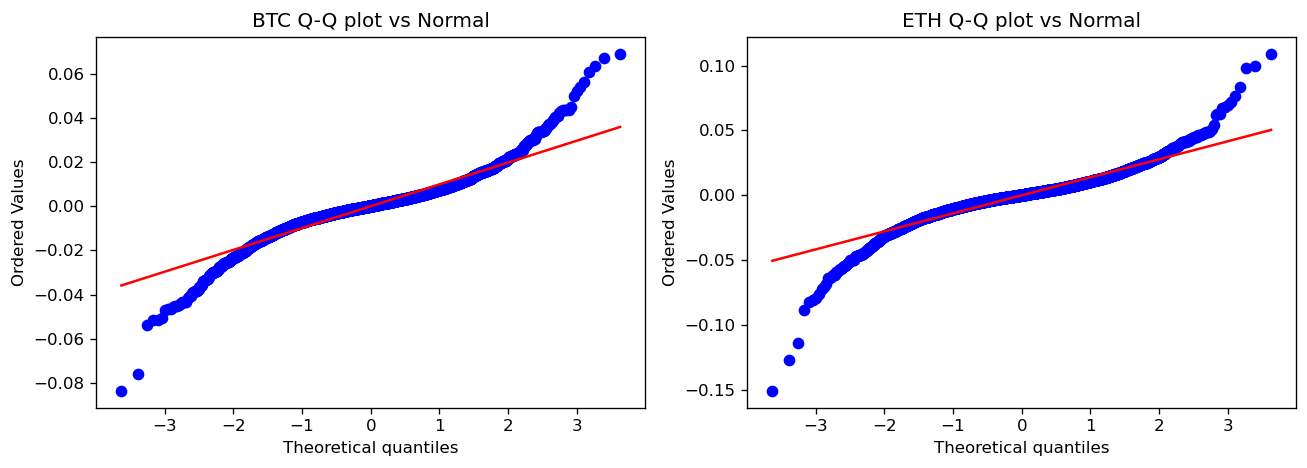

In [14]:
# Q-Q plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
probplot(df["btc"], dist="norm", plot=axes[0])
axes[0].set_title("BTC Q-Q plot vs Normal")
probplot(df["eth"], dist="norm", plot=axes[1])
axes[1].set_title("ETH Q-Q plot vs Normal")
plt.tight_layout()
plt.show()

In [15]:
# Dependence structure
pearson = df["btc"].corr(df["eth"])
spearman = _extract_stat(spearmanr(df["btc"], df["eth"]))
kendall = _extract_stat(kendalltau(df["btc"], df["eth"]))

u_btc = rankdata(df["btc"], method="average") / (len(df) + 1.0)
u_eth = rankdata(df["eth"], method="average") / (len(df) + 1.0)

# Gaussian-copula style rank-to-normal transform
z_btc = norm.ppf(u_btc)
z_eth = norm.ppf(u_eth)
gauss_copula_rho = np.corrcoef(z_btc, z_eth)[0, 1]

dep_summary = pd.DataFrame({
    "Measure": ["Pearson", "Spearman", "Kendall tau", "Gaussian-copula rho"],
    "Value": [pearson, spearman, kendall, gauss_copula_rho]
})
dep_summary

,Measure,Value
0,Pearson,0.811943
1,Spearman,0.783401
2,Kendall tau,0.604509
3,Gaussian-copula rho,0.804052


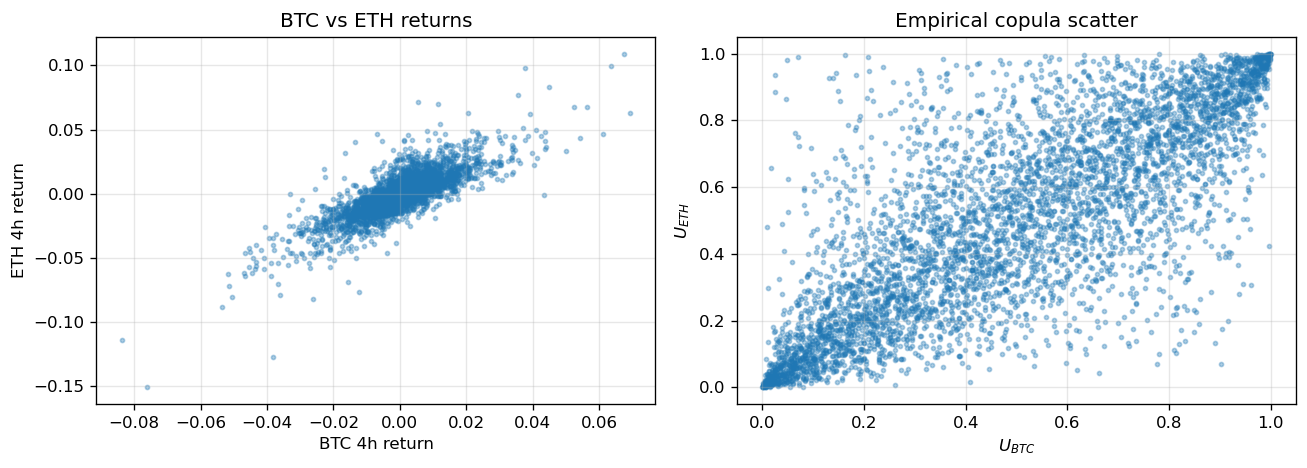

In [16]:
# Scatter in return space and copula space
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(df["btc"], df["eth"], s=6, alpha=0.35)
axes[0].set_title("BTC vs ETH returns")
axes[0].set_xlabel("BTC 4h return")
axes[0].set_ylabel("ETH 4h return")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(u_btc, u_eth, s=6, alpha=0.35)
axes[1].set_title("Empirical copula scatter")
axes[1].set_xlabel("$U_{BTC}$")
axes[1].set_ylabel("$U_{ETH}$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Empirical tail co-exceedance
def conditional_coexceed(u, v, q):
    lower = np.mean(v[u < q] < q) if np.any(u < q) else np.nan
    upper = np.mean(v[u > 1-q] > 1-q) if np.any(u > 1-q) else np.nan
    return lower, upper

tail5 = conditional_coexceed(u_btc, u_eth, 0.05)
tail1 = conditional_coexceed(u_btc, u_eth, 0.01)

tail_dep = pd.DataFrame({
    "Level": ["5%", "1%"],
    "Lower-tail co-movement": [tail5[0], tail1[0]],
    "Upper-tail co-movement": [tail5[1], tail1[1]],
})
tail_dep

,Level,Lower-tail co-movement,Upper-tail co-movement
0,5%,0.641975,0.497942
1,1%,0.604167,0.437500


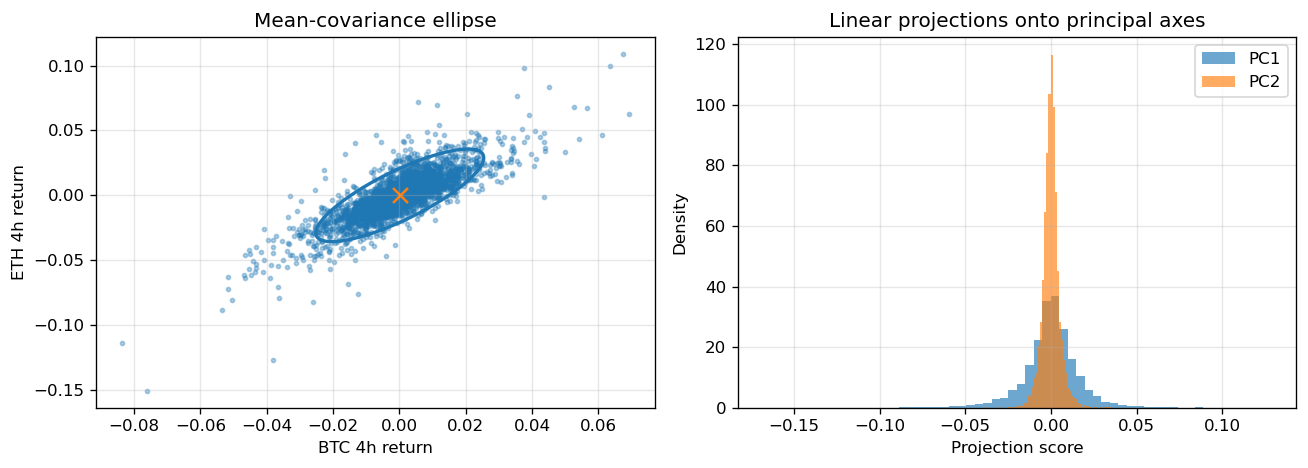

,eigenvalue,explained_variance_ratio
PC1,0.000293,0.917301
PC2,0.000026,0.082699


In [18]:
# Mean-covariance ellipse and PCA
mean_xy = df[["btc", "eth"]].mean().to_numpy()
cov_xy = df[["btc", "eth"]].cov().to_numpy()

eigvals, eigvecs = eigh(cov_xy)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]
explained = eigvals / eigvals.sum()

theta = np.linspace(0, 2*np.pi, 400)
circle = np.vstack((np.cos(theta), np.sin(theta)))
c95 = chi2.ppf(0.95, df=2)
ellipse = mean_xy.reshape(2,1) + eigvecs @ np.diag(np.sqrt(c95 * eigvals)) @ circle

pc_scores = (df[["btc", "eth"]].to_numpy() - mean_xy) @ eigvecs

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(df["btc"], df["eth"], s=6, alpha=0.35)
axes[0].plot(ellipse[0], ellipse[1], lw=2)
axes[0].scatter(mean_xy[0], mean_xy[1], marker='x', s=80)
axes[0].set_title("Mean-covariance ellipse")
axes[0].set_xlabel("BTC 4h return")
axes[0].set_ylabel("ETH 4h return")
axes[0].grid(True, alpha=0.3)

axes[1].hist(pc_scores[:,0], bins=60, density=True, alpha=0.65, label="PC1")
axes[1].hist(pc_scores[:,1], bins=60, density=True, alpha=0.65, label="PC2")
axes[1].set_title("Linear projections onto principal axes")
axes[1].set_xlabel("Projection score")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pca_summary = pd.DataFrame({
    "eigenvalue": eigvals,
    "explained_variance_ratio": explained
}, index=["PC1", "PC2"])
pca_summary

### Interpretation of the empirical findings

- **Probability density:** Both BTC and ETH 4-hour returns are more sharply peaked and have heavier tails than a Gaussian distribution with matching mean and variance.
- **Stylized facts:** Both series show heavy tails and negative skewness; ETH is the more negatively skewed and more heavy-tailed of the two.
- **Q-Q plots:** The tails depart clearly from the normal reference line, confirming non-Gaussian behavior.
- **Dependence:** BTC and ETH exhibit strong positive dependence in both return space and copula space.
- **Tail co-movement proxy:** The empirical co-exceedance rates suggest stronger lower-tail co-movement than upper-tail co-movement, rather than establishing the asymptotic tail-dependence coefficient itself.
- **Mean-covariance view:** The first principal component explains the overwhelming majority of the joint variance, which is typical of a strong common market factor.
